# TinyML — Self-Organizing Maps (SOM)

**Author:** Thommas Kevin Sales Flores  
**Institution:** Federal University of Rio Grande do Norte  
**Email:** thommas.flores@ufrn.br

---

This notebook demonstrates how to build, train, evaluate, and export
**Self-Organizing Maps (SOMs)** to embedded hardware (Arduino / ESP32)
using the TinyML framework.

A SOM projects high-dimensional data onto a compact 2-D lattice while
preserving the topological structure of the input space — nearby
neurons represent similar regions of the data manifold.

### Supported building blocks

| Component | Options |
|---|---|
| **Neighborhood kernel** | `gaussian`, `mexican_hat`, `bubble`, `epanechnikov` |
| **LR / sigma schedule** | `exponential`, `linear`, `inverse_time`, `cyclical` |
| **Distance metric** | `euclidean`, `manhattan`, `cosine` |
| **Topology** | `rectangular`, `hexagonal` |
| **Training mode** | `online` (sequential), `batch` (Kohonen) |
| **Export** | JSON -> Arduino C++ (AVR PROGMEM or ESP32) |


## Environment Setup


In [1]:
#!pip install torch numpy matplotlib scikit-learn

In [2]:
import sys, os
sys.path.append('40_SOM')   # adjust to your directory

import numpy as np
from sklearn.datasets import load_iris, make_blobs, load_digits
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split

from model  import SOMModel
from layers import KERNEL_NAMES, SCHEDULE_NAMES
from losses import LOSS_NAMES, compute_loss
from utils  import (
    export_to_json,
    train_model,
    plot_training_history,
    plot_umatrix,
    plot_component_planes,
    plot_winner_map,
    plot_som_scatter,
    plot_weight_trajectories,
    plot_calibration,
    evaluate_metrics,
)
from cpp_generator import generate_ino

print('Neighborhood kernels :', KERNEL_NAMES)
print('LR/sigma schedules   :', SCHEDULE_NAMES)
print('Quality metrics      :', LOSS_NAMES)

os.makedirs('json_model',   exist_ok=True)
os.makedirs('arduino_code', exist_ok=True)

Neighborhood kernels : ['gaussian', 'mexican_hat', 'bubble', 'epanechnikov']
LR/sigma schedules   : ['linear', 'exponential', 'inverse_time', 'cyclical']
Quality metrics      : ['quantization_error', 'topographic_error', 'reconstruction_error', 'entropy', 'kl_divergence', 'silhouette']


---
## Example 1 — Iris Dataset: 2-D Topology Preservation

We train a 10x10 SOM on the 4-feature Iris dataset and verify that
the three species (setosa, versicolor, virginica) are mapped to
distinct, topologically separated regions of the 2-D grid.

The U-matrix visualises cluster boundaries, the component planes show
which grid regions correspond to high values of each petal/sepal feature,
and the hit map shows which neurons are most frequently activated.

=== Example 1 — Iris SOM ===
  Epoch    1/200  |  alpha = 0.50000  |  sigma = 5.0000  |  QE = 0.241842
  Epoch   41/200  |  alpha = 0.22776  |  sigma = 3.6180  |  QE = 0.169208
  Epoch   81/200  |  alpha = 0.10374  |  sigma = 2.6180  |  QE = 0.135071
  Epoch  121/200  |  alpha = 0.04726  |  sigma = 1.8944  |  QE = 0.108315
  Epoch  161/200  |  alpha = 0.02153  |  sigma = 1.3708  |  QE = 0.092840
  Epoch  200/200  |  alpha = 0.01000  |  sigma = 1.0000  |  QE = 0.083287


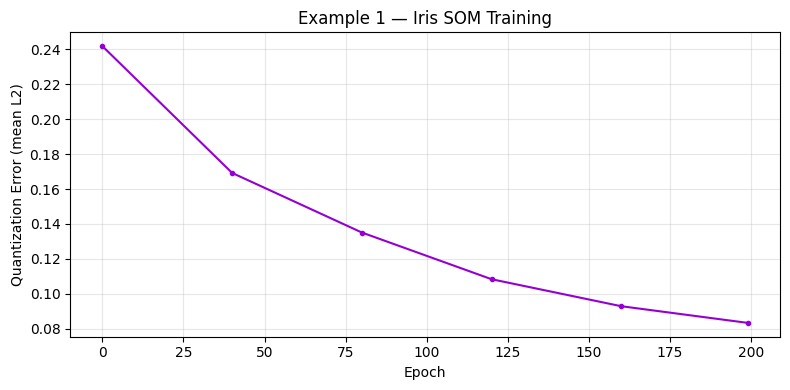

In [3]:
print('=== Example 1 — Iris SOM ===')

iris = load_iris()
X_iris = MinMaxScaler().fit_transform(iris.data).astype(np.float32)
y_iris = iris.target

som1 = SOMModel(
    n_rows=10, n_cols=10, input_dim=4,
    topology='rectangular',
    kernel='gaussian',
    lr_schedule='exponential',
    sigma_schedule='exponential',
    lr_0=0.5, lr_min=0.01,
    sigma_0=5.0, sigma_min=1.0,
    init='pca',
    random_state=42,
)
history1 = train_model(som1, X_iris, n_epochs=200, mode='online', log_every=40)
plot_training_history(history1, title='Example 1 — Iris SOM Training')

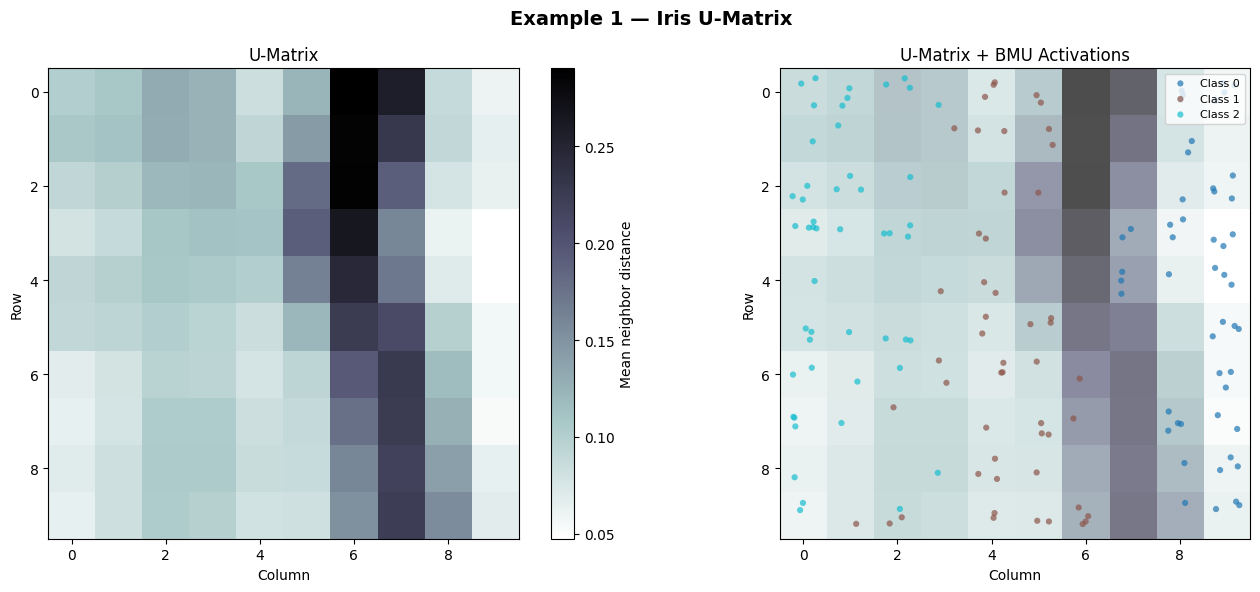

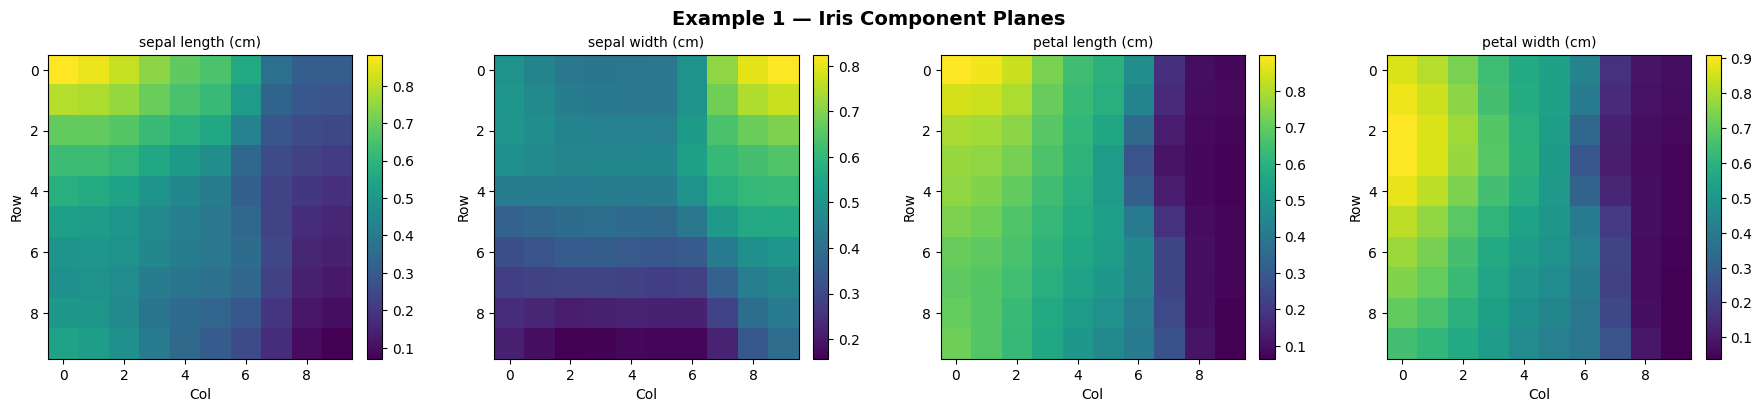

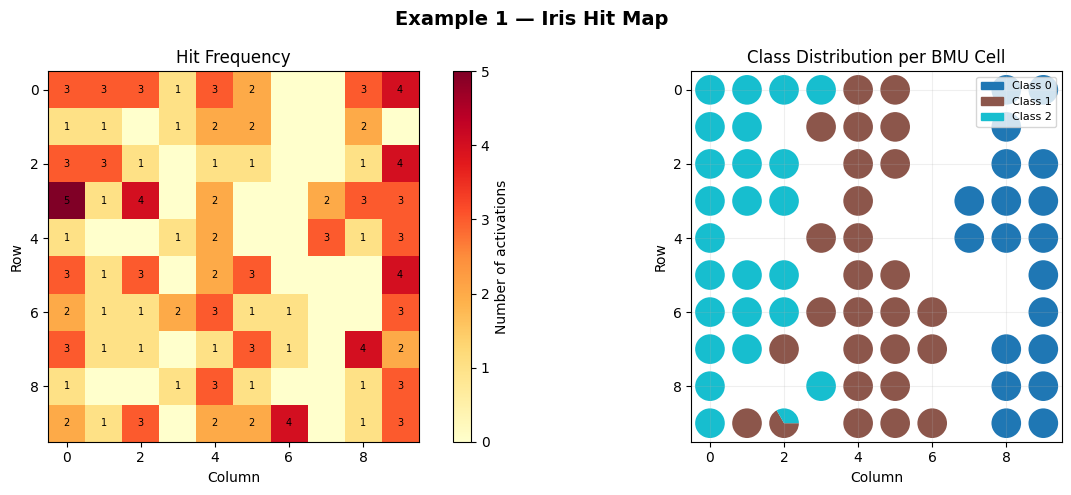

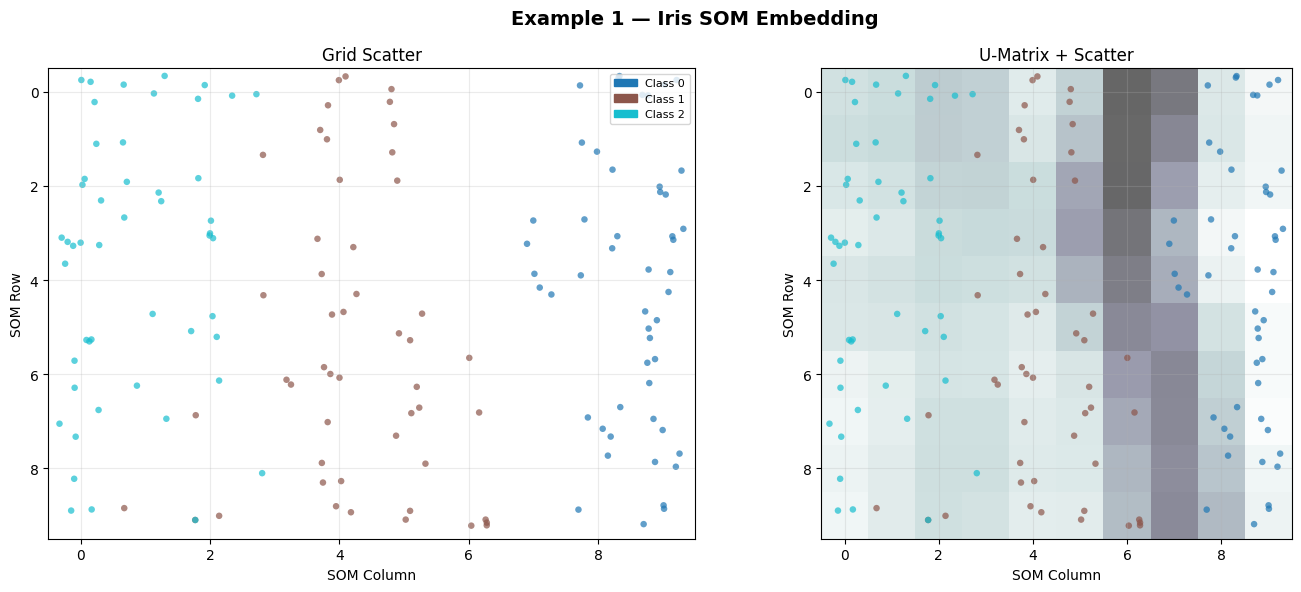


Metrics:
  quantization_error           = 0.083287
  reconstruction_error         = 0.009452
  topographic_error            = 0.000000
  bmu_entropy                  = 4.122403
  kl_divergence                = 0.482767
  dead_neurons_pct             = 30.000000
  weight_smoothness            = 0.004119
  silhouette                   = 0.449141


In [4]:
# U-matrix with class overlay
plot_umatrix(som1, X_iris, y_iris,
             title='Example 1 — Iris U-Matrix')

# Component planes (one per feature)
plot_component_planes(som1,
    feature_names=iris.feature_names,
    title='Example 1 — Iris Component Planes')

# Winner (hit) map
plot_winner_map(som1, X_iris, y_iris,
                title='Example 1 — Iris Hit Map')

# 2-D SOM scatter
plot_som_scatter(som1, X_iris, y_iris,
                 title='Example 1 — Iris SOM Embedding')

# Metrics
m1 = evaluate_metrics(som1, X_iris, y_iris)
print('\nMetrics:')
for k, v in m1.items():
    print(f'  {k:28s} = {v:.6f}')

In [5]:
export_to_json(som1, 'json_model/som_iris.json')
generate_ino(
    json_path='json_model/som_iris.json',
    output_dir='arduino_code/iris_ino',
    board='esp32',
    task='cluster',
    sample_x=X_iris[0],
)

Model exported -> json_model/som_iris.json
Header  -> arduino_code/iris_ino\SOMModel.h
Sketch  -> arduino_code/iris_ino\sketch.ino
Reference BMU: flat=39  row=3  col=9


---
## Example 2 — Hexagonal Topology with Mexican Hat Kernel

We train a hexagonal SOM on a synthetic 5-cluster dataset using the
**Mexican Hat** kernel.  The lateral inhibition ring of the Mexican Hat
kernel sharpens cluster boundaries at the cost of occasional instability,
producing a more distinct separation between cluster regions than the
standard Gaussian.

We also compare convergence of four neighborhood kernels side by side.

=== Example 2 — Hexagonal SOM with Mexican Hat Kernel ===


c:\Users\thomm\OneDrive\Desktop\Repositorios\TinyML\40_SOM\model.py:215: RuntimeWarning: overflow encountered in square
  W_sq    = (w_flat ** 2).sum(axis=1, keepdims=True).T  # (1, K)


  Epoch    1/300  |  alpha = 0.40000  |  sigma = 6.0000  |  QE = 0.280455


c:\Users\thomm\OneDrive\Desktop\Repositorios\TinyML\40_SOM\model.py:297: RuntimeWarning: overflow encountered in add
  self.weights += alpha * h[:, :, np.newaxis] * delta
c:\Users\thomm\OneDrive\Desktop\Repositorios\TinyML\40_SOM\model.py:297: RuntimeWarning: invalid value encountered in add
  self.weights += alpha * h[:, :, np.newaxis] * delta
c:\Users\thomm\OneDrive\Desktop\Repositorios\TinyML\40_SOM\model.py:216: RuntimeWarning: invalid value encountered in matmul
  XW      = X @ w_flat.T                       # (N, K)


  Epoch   61/300  |  alpha = 0.19080  |  sigma = 4.1879  |  QE = inf
  Epoch  121/300  |  alpha = 0.09101  |  sigma = 2.9231  |  QE = inf
  Epoch  181/300  |  alpha = 0.04341  |  sigma = 2.0403  |  QE = inf


c:\Users\thomm\OneDrive\Desktop\Repositorios\TinyML\40_SOM\model.py:297: RuntimeWarning: invalid value encountered in multiply
  self.weights += alpha * h[:, :, np.newaxis] * delta


  Epoch  241/300  |  alpha = 0.02071  |  sigma = 1.4241  |  QE = inf
  Epoch  300/300  |  alpha = 0.01000  |  sigma = 1.0000  |  QE = nan


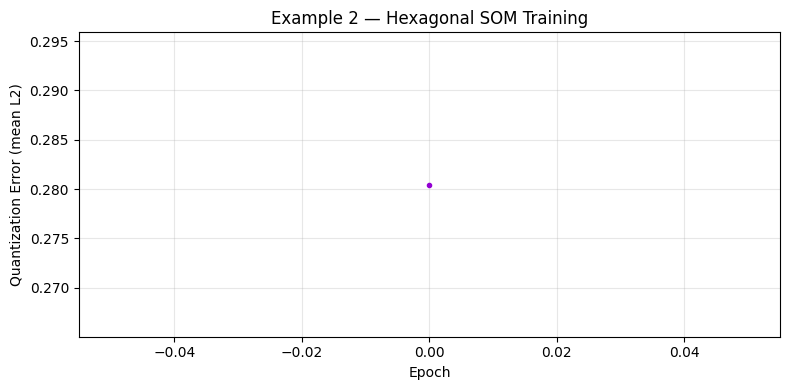

In [6]:
print('=== Example 2 — Hexagonal SOM with Mexican Hat Kernel ===')

X_blob, y_blob = make_blobs(
    n_samples=600, centers=5, n_features=6,
    cluster_std=1.2, random_state=7,
)
X_blob = MinMaxScaler().fit_transform(X_blob).astype(np.float32)

som2 = SOMModel(
    n_rows=12, n_cols=12, input_dim=6,
    topology='hexagonal',
    kernel='mexican_hat',
    lr_schedule='exponential',
    sigma_schedule='exponential',
    lr_0=0.4, lr_min=0.01,
    sigma_0=6.0, sigma_min=1.0,
    init='pca',
    random_state=7,
)
history2 = train_model(som2, X_blob, n_epochs=300, mode='online', log_every=60)
plot_training_history(history2, title='Example 2 — Hexagonal SOM Training')

c:\Users\thomm\OneDrive\Desktop\Repositorios\TinyML\40_SOM\model.py:417: RuntimeWarning: invalid value encountered in subtract
  np.linalg.norm(self.weights[r, c] - self.weights[nr, nc])
c:\Users\thomm\OneDrive\Desktop\Repositorios\TinyML\.venv_new_python\Lib\site-packages\numpy\linalg\_linalg.py:2767: RuntimeWarning: overflow encountered in dot
  sqnorm = x.dot(x)


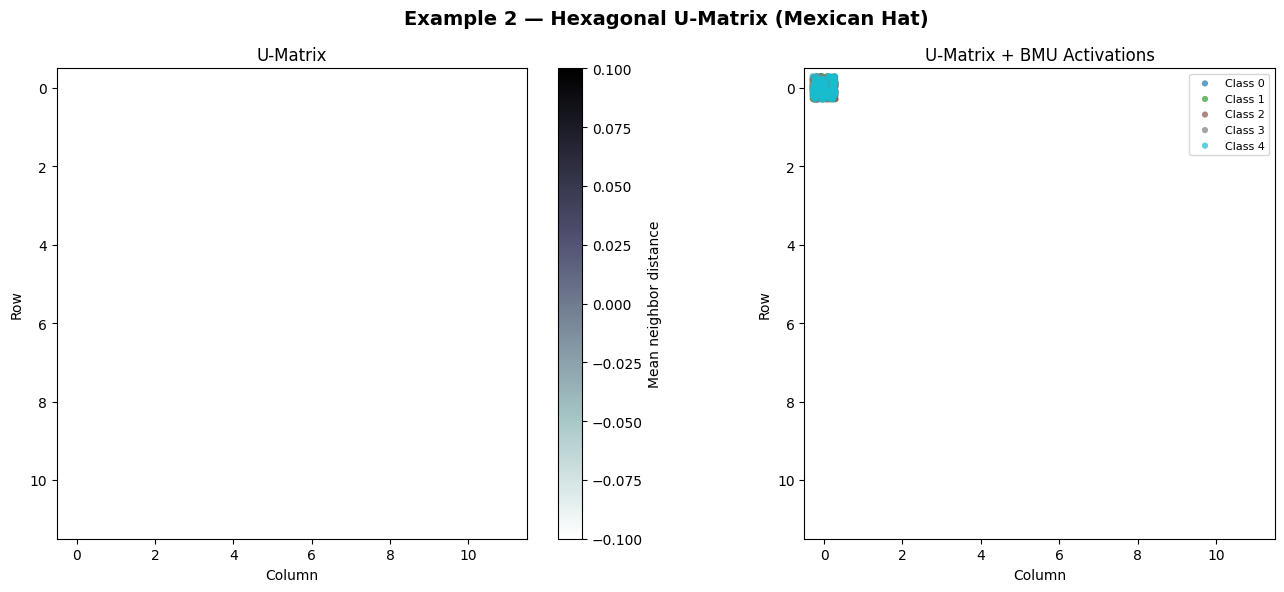

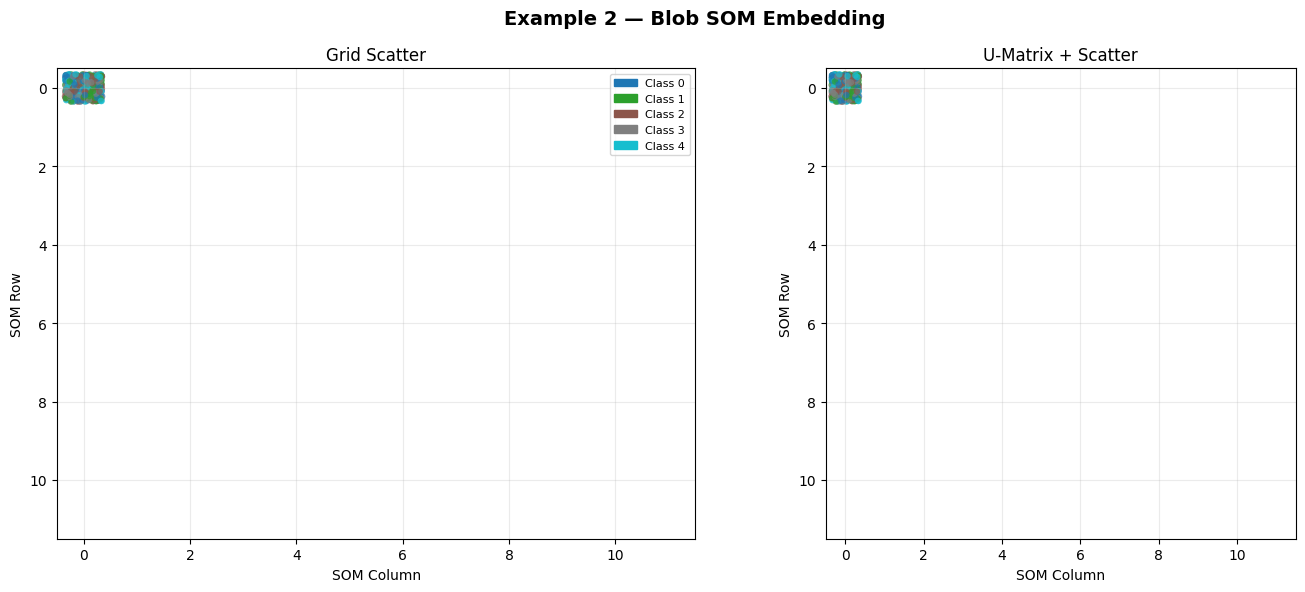

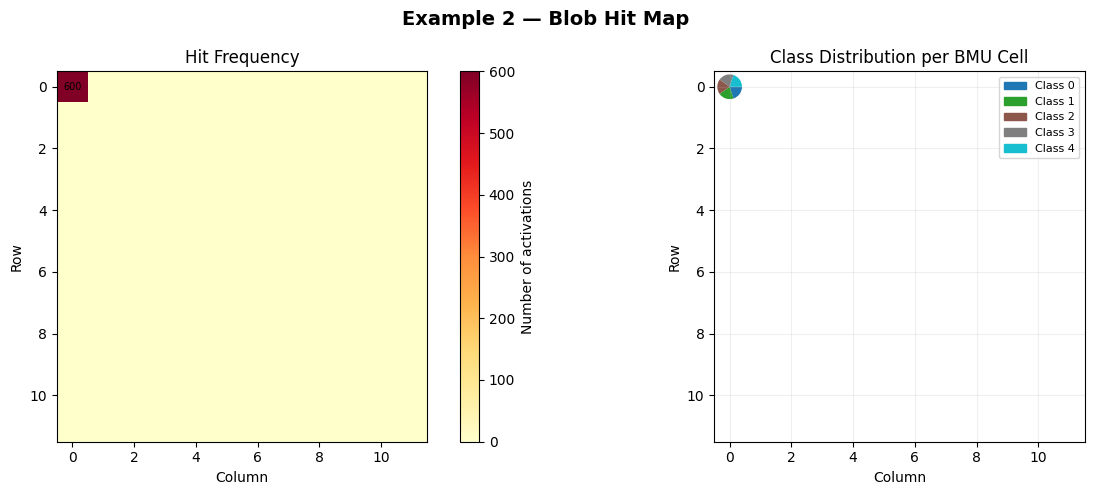

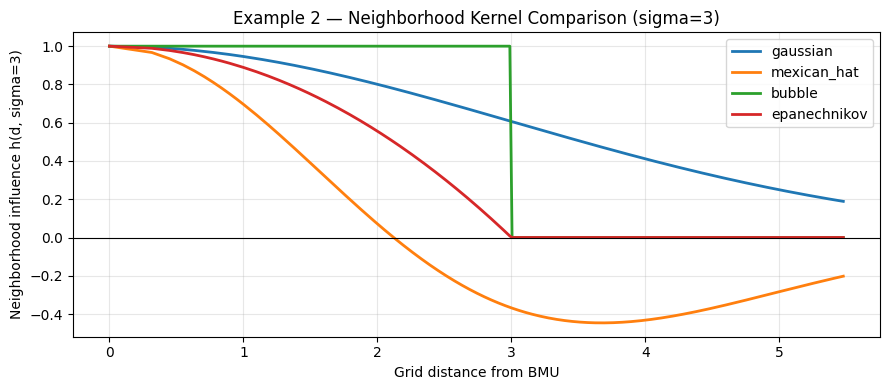


Metrics:
  quantization_error           = nan
  reconstruction_error         = nan
  topographic_error            = 1.000000
  bmu_entropy                  = -0.000000
  kl_divergence                = 4.969813
  dead_neurons_pct             = 99.305556
  weight_smoothness            = nan
  silhouette                   = 0.000000


c:\Users\thomm\OneDrive\Desktop\Repositorios\TinyML\.venv_new_python\Lib\site-packages\numpy\linalg\_linalg.py:2803: RuntimeWarning: overflow encountered in multiply
  s = (x.conj() * x).real
c:\Users\thomm\OneDrive\Desktop\Repositorios\TinyML\40_SOM\vi.py:88: RuntimeWarning: invalid value encountered in subtract
  diff   = w[r_src, c_src] - w[r_dst, c_dst]
c:\Users\thomm\OneDrive\Desktop\Repositorios\TinyML\40_SOM\vi.py:89: RuntimeWarning: overflow encountered in square
  total += float((diff ** 2).sum())


In [7]:
plot_umatrix(som2, X_blob, y_blob,
             title='Example 2 — Hexagonal U-Matrix (Mexican Hat)')
plot_som_scatter(som2, X_blob, y_blob,
                 title='Example 2 — Blob SOM Embedding')
plot_winner_map(som2, X_blob, y_blob,
                title='Example 2 — Blob Hit Map')

# Kernel comparison
import matplotlib.pyplot as plt
from layers import KERNELS
import numpy as np

d_sq = np.linspace(0, 30, 300)
fig, ax = plt.subplots(figsize=(9, 4))
for kname, kfn in KERNELS.items():
    ax.plot(np.sqrt(d_sq), kfn(d_sq, sigma=3.0), label=kname, linewidth=2)
ax.axhline(0, color='black', linewidth=0.8)
ax.set_xlabel('Grid distance from BMU')
ax.set_ylabel('Neighborhood influence h(d, sigma=3)')
ax.set_title('Example 2 — Neighborhood Kernel Comparison (sigma=3)')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

m2 = evaluate_metrics(som2, X_blob, y_blob)
print('\nMetrics:')
for k, v in m2.items():
    print(f'  {k:28s} = {v:.6f}')

In [8]:
export_to_json(som2, 'json_model/som_hex.json')
generate_ino(
    json_path='json_model/som_hex.json',
    output_dir='arduino_code/hex_ino',
    board='avr',
    use_flash=True,
    task='cluster',
)

c:\Users\thomm\OneDrive\Desktop\Repositorios\TinyML\40_SOM\cpp_generator.py:74: RuntimeWarning: overflow encountered in square
  dists  = (diff ** 2).sum(axis=1)


Model exported -> json_model/som_hex.json
Header  -> arduino_code/hex_ino\SOMModel.h
Sketch  -> arduino_code/hex_ino\sketch.ino
Reference BMU: flat=0  row=0  col=0


---
## Example 3 — Weight Trajectories and Schedule Comparison

This example captures weight snapshots at regular intervals during training
and visualises how individual neurons migrate through feature space.

We also compare all four learning-rate schedules on the same dataset,
plotting their decay curves and final quantization errors side by side.

=== Example 3 — Weight Trajectories and Schedule Comparison ===
  Epoch 30/150  snapshot saved
  Epoch 60/150  snapshot saved
  Epoch 90/150  snapshot saved
  Epoch 120/150  snapshot saved
  Epoch 150/150  snapshot saved


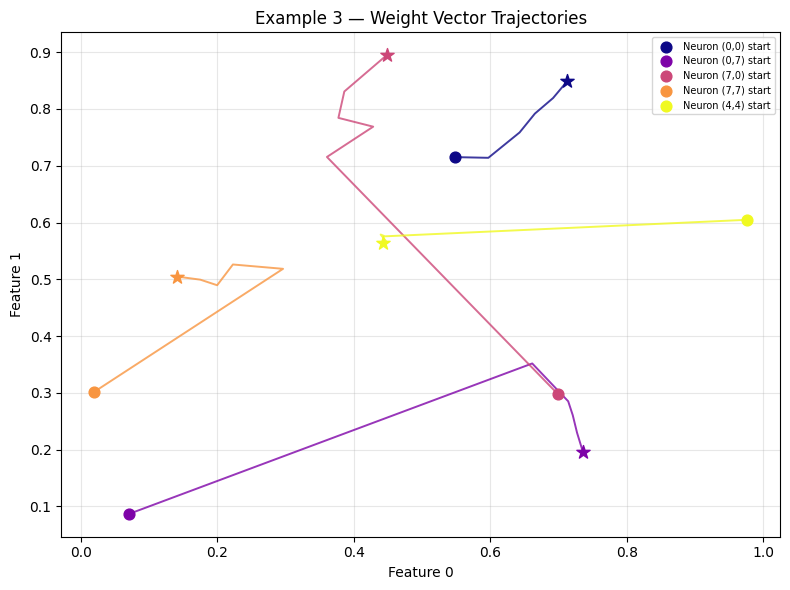

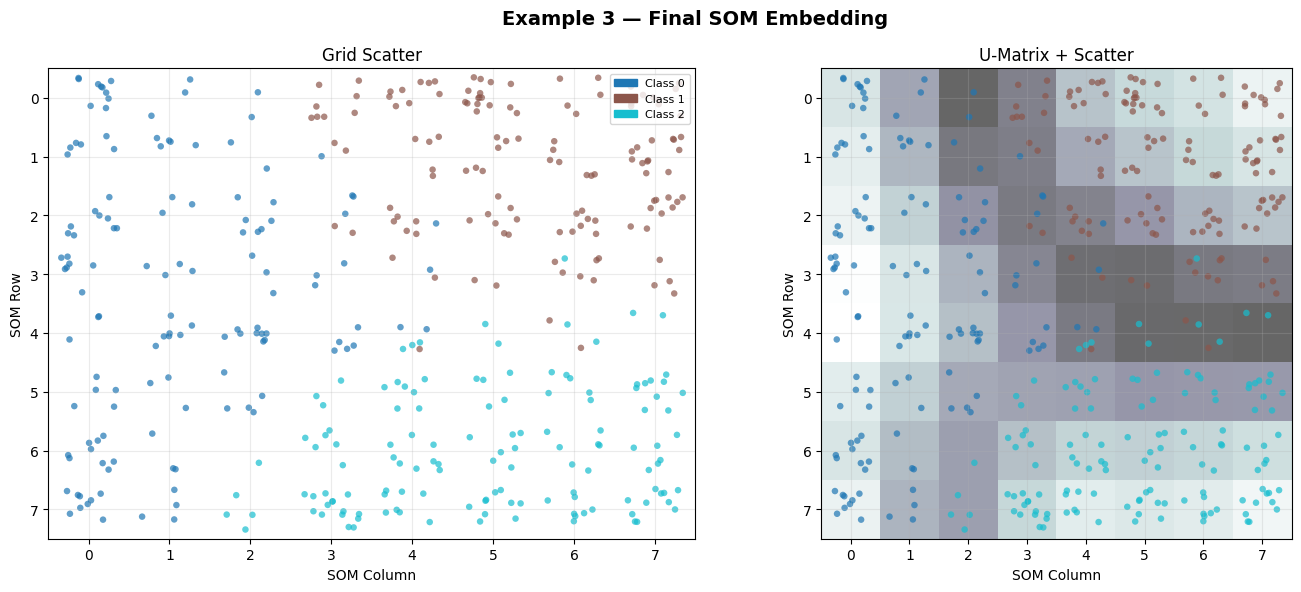

In [9]:
print('=== Example 3 — Weight Trajectories and Schedule Comparison ===')

from layers import LearningRateSchedule, SCHEDULE_NAMES
import matplotlib.pyplot as plt

X_tr, y_tr = make_blobs(
    n_samples=400, centers=3, n_features=2,
    cluster_std=0.8, random_state=0,
)
X_tr = MinMaxScaler().fit_transform(X_tr).astype(np.float32)

# ---- Train with snapshots ----
som3 = SOMModel(
    n_rows=8, n_cols=8, input_dim=2,
    topology='rectangular',
    kernel='gaussian',
    lr_0=0.5, sigma_0=4.0,
    init='random', random_state=0,
)
som3._init_weights(X_tr)

N_EPOCHS   = 150
SNAP_EVERY = 30
snapshots  = [som3.weights.copy()]

from layers import LearningRateSchedule, NeighborhoodKernel, GridTopology
lr_s  = LearningRateSchedule('exponential', 0.5, 0.01, N_EPOCHS)
sig_s = LearningRateSchedule('exponential', 4.0, 1.0, N_EPOCHS)

for ep in range(N_EPOCHS):
    alpha = lr_s(ep)
    sigma = sig_s(ep)
    for x in X_tr[np.random.permutation(len(X_tr))]:
        som3._online_step(x, alpha, sigma)
    if (ep + 1) % SNAP_EVERY == 0:
        snapshots.append(som3.weights.copy())
        print(f'  Epoch {ep+1}/{N_EPOCHS}  snapshot saved')

# ---- Plot trajectories for corner neurons ----
neurons = [(0,0), (0,7), (7,0), (7,7), (4,4)]
plot_weight_trajectories(
    snapshots, neurons,
    feature_pair=(0, 1),
    title='Example 3 — Weight Vector Trajectories',
)
plot_som_scatter(som3, X_tr, y_tr,
                 title='Example 3 — Final SOM Embedding')

  linear           QE = 0.044054
  exponential      QE = 0.044194
  inverse_time     QE = 0.068429
  cyclical         QE = 0.126216


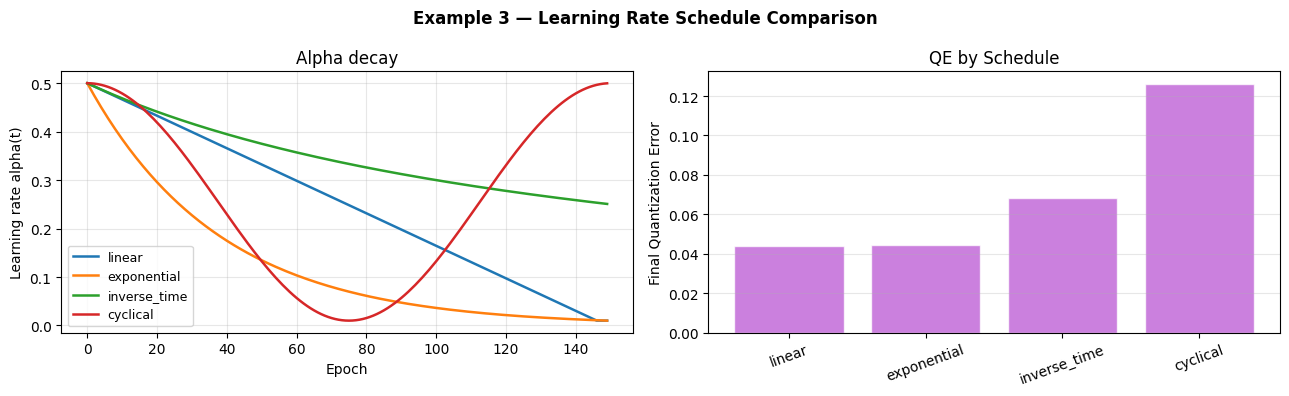

In [10]:
# ---- Schedule comparison ----
epochs = np.arange(N_EPOCHS)
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
fig.suptitle('Example 3 — Learning Rate Schedule Comparison', fontweight='bold')

for sname in SCHEDULE_NAMES:
    sched = LearningRateSchedule(sname, 0.5, 0.01, N_EPOCHS)
    vals  = [sched(t) for t in epochs]
    axes[0].plot(epochs, vals, label=sname, linewidth=1.8)

axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Learning rate alpha(t)')
axes[0].set_title('Alpha decay')
axes[0].legend(fontsize=9)
axes[0].grid(True, alpha=0.3)

qe_by_schedule = {}
for sname in SCHEDULE_NAMES:
    s_tmp = SOMModel(
        n_rows=8, n_cols=8, input_dim=2,
        kernel='gaussian', lr_schedule=sname,
        sigma_schedule=sname,
        lr_0=0.5, sigma_0=4.0, random_state=0,
    )
    s_tmp.fit(X_tr, n_epochs=N_EPOCHS, verbose=False)
    bmus = s_tmp.predict(X_tr)
    from losses import quantization_error
    qe   = quantization_error(X_tr, bmus, s_tmp.weights)
    qe_by_schedule[sname] = qe
    print(f'  {sname:15s}  QE = {qe:.6f}')

axes[1].bar(list(qe_by_schedule.keys()), list(qe_by_schedule.values()),
            color='mediumorchid', alpha=0.75, edgecolor='white')
axes[1].set_ylabel('Final Quantization Error')
axes[1].set_title('QE by Schedule')
axes[1].tick_params(axis='x', rotation=20)
axes[1].grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

In [11]:
export_to_json(som3, 'json_model/som_traj.json')
generate_ino(
    json_path='json_model/som_traj.json',
    output_dir='arduino_code/traj_ino',
    board='esp32',
    task='quantize',
    sample_x=X_tr[0],
)

Model exported -> json_model/som_traj.json
Header  -> arduino_code/traj_ino\SOMModel.h
Sketch  -> arduino_code/traj_ino\sketch.ino
Reference BMU: flat=54  row=6  col=6


---
## Example 4 — Digits Dataset: Large Map + Batch Training

We train a 20x20 SOM on the 64-feature Digits dataset (8x8 grayscale images
of handwritten digits 0-9) using **batch mode** training and **PCA
initialisation**.

Batch training updates all weight vectors simultaneously from the entire
dataset at each epoch, converging faster than online mode for large, dense
datasets.  PCA initialisation ensures the map is already roughly ordered
before competitive training begins, reducing the number of epochs needed
for full convergence.

We also apply the SOM-KL soft assignment loss from ``vi.py`` to quantify
clustering confidence after training.

=== Example 4 — Digits SOM (Batch, 20x20, PCA init) ===
  Epoch    1/50  |  alpha = 0.50000  |  sigma = 10.0000  |  QE = 1.952723
  Epoch   11/50  |  alpha = 0.22503  |  sigma = 6.2506  |  QE = 1.761948
  Epoch   21/50  |  alpha = 0.10128  |  sigma = 3.9069  |  QE = 1.592293
  Epoch   31/50  |  alpha = 0.04558  |  sigma = 2.4421  |  QE = 1.416736
  Epoch   41/50  |  alpha = 0.02051  |  sigma = 1.5264  |  QE = 1.256962
  Epoch   50/50  |  alpha = 0.01000  |  sigma = 1.0000  |  QE = 1.127255


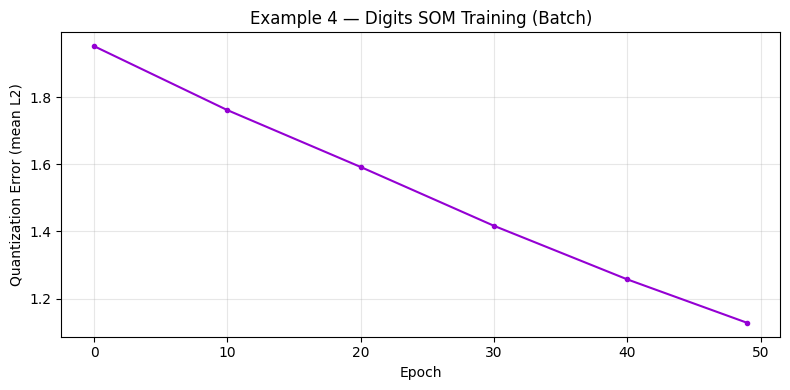

In [12]:
print('=== Example 4 — Digits SOM (Batch, 20x20, PCA init) ===')

digits = load_digits()
X_dig  = MinMaxScaler().fit_transform(digits.data).astype(np.float32)
y_dig  = digits.target

som4 = SOMModel(
    n_rows=20, n_cols=20, input_dim=64,
    topology='rectangular',
    kernel='gaussian',
    lr_schedule='exponential',
    sigma_schedule='exponential',
    lr_0=0.5, lr_min=0.01,
    sigma_0=10.0, sigma_min=1.0,
    init='pca',
    random_state=42,
)
history4 = train_model(
    som4, X_dig,
    n_epochs=50,
    mode='batch',
    log_every=10,
)
plot_training_history(history4, title='Example 4 — Digits SOM Training (Batch)')

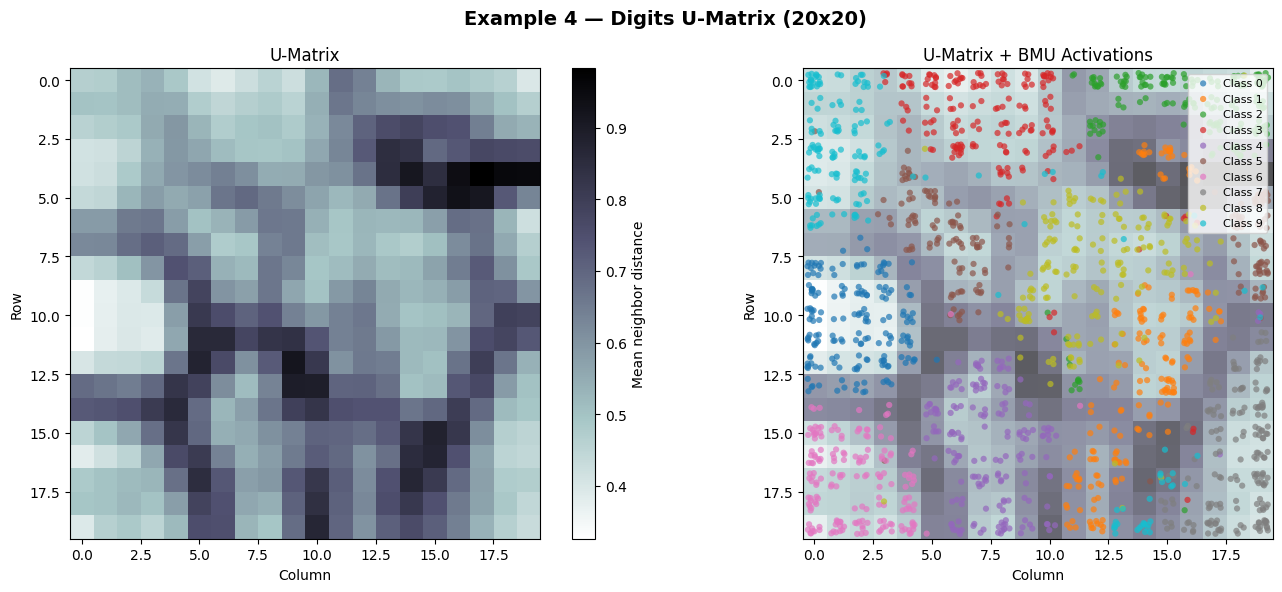

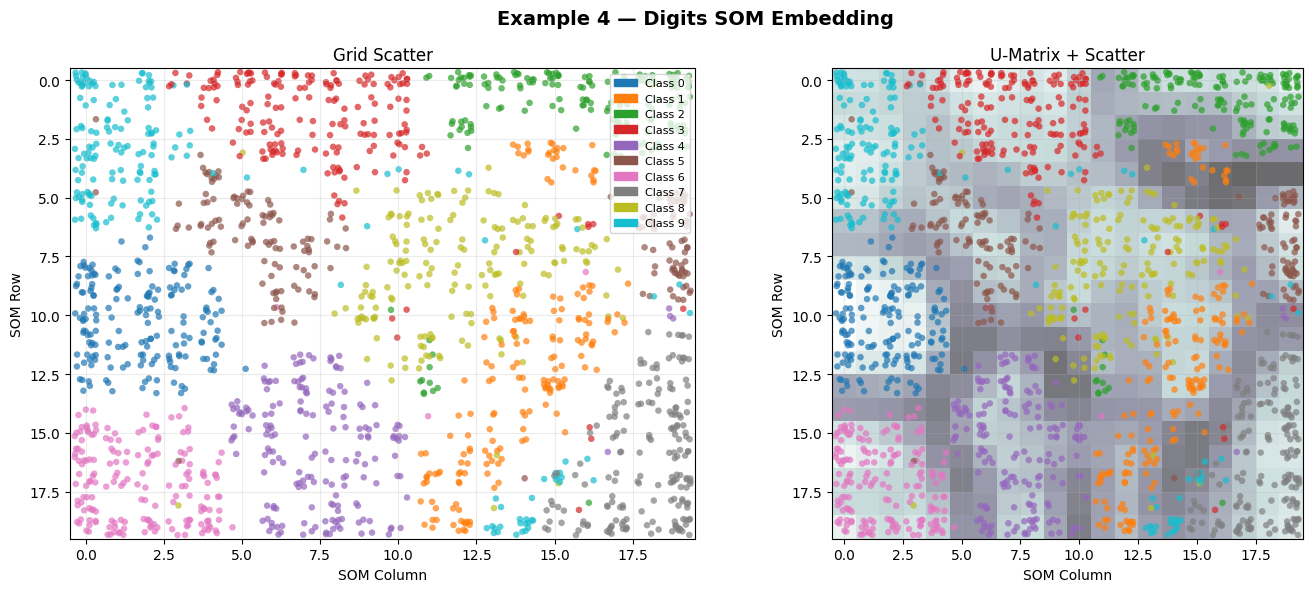

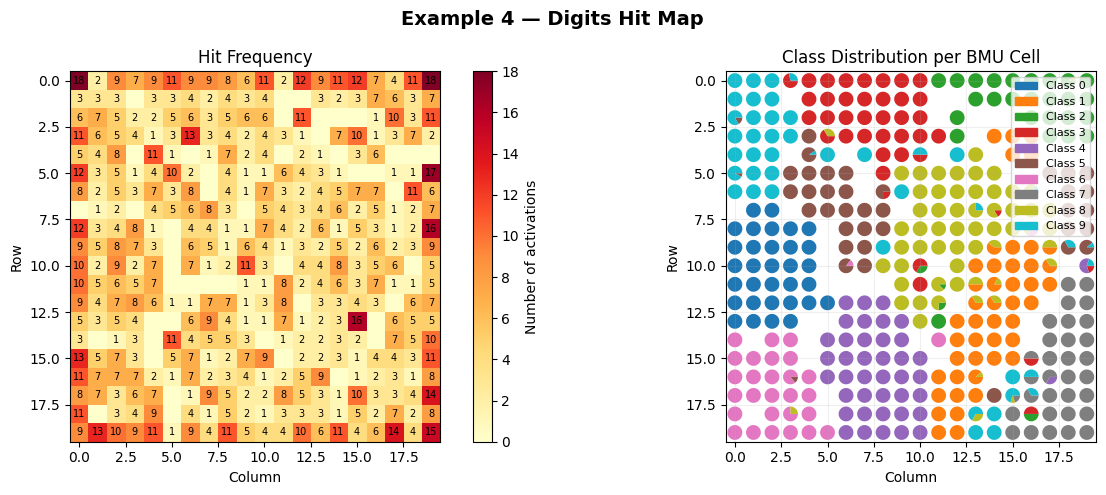

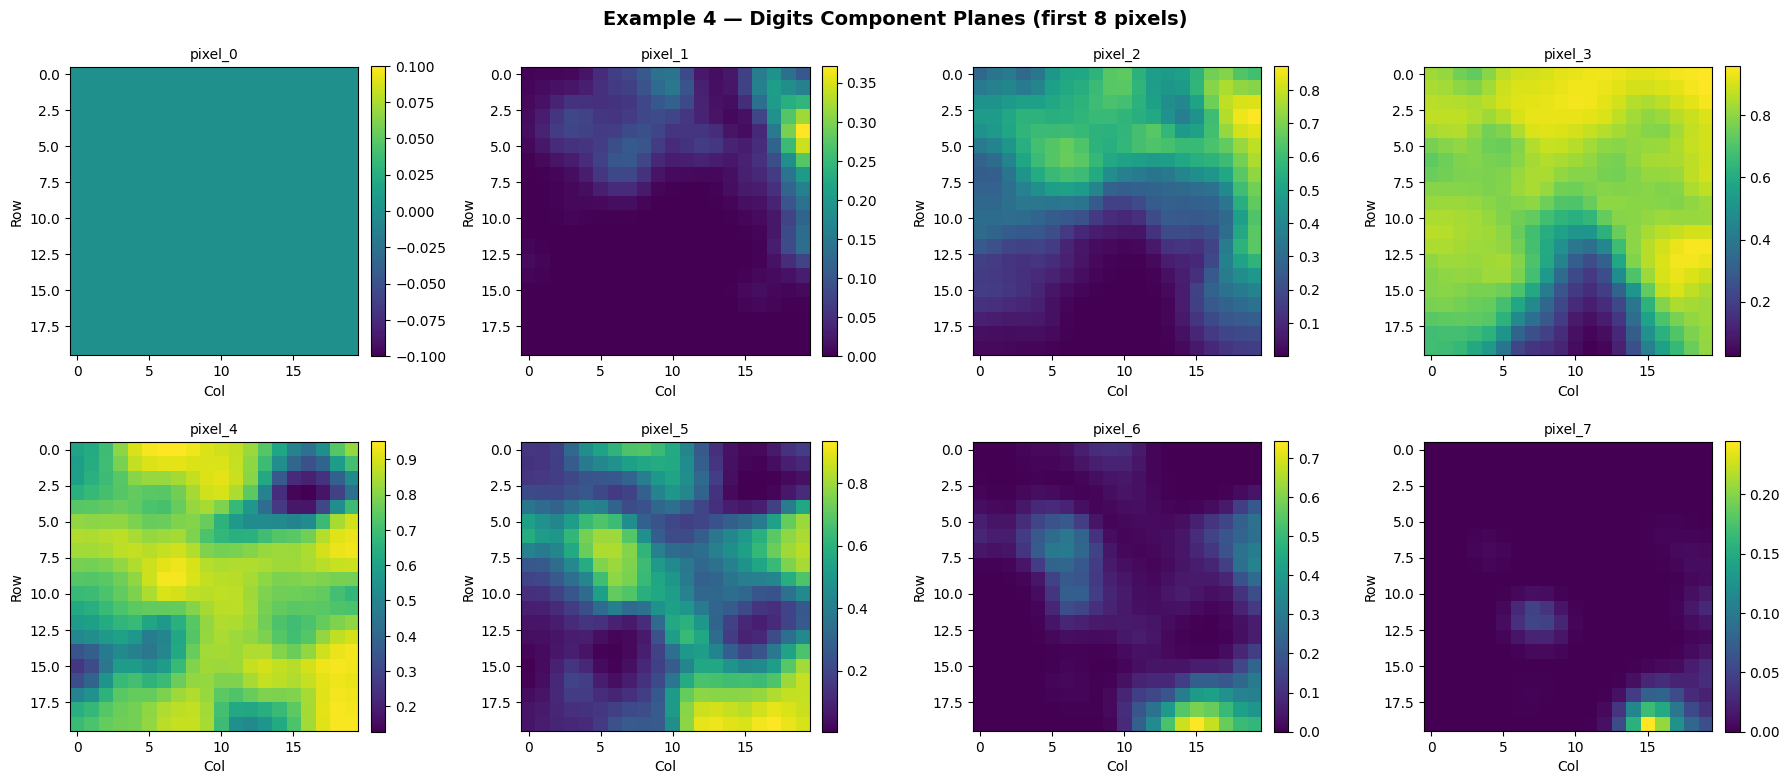


SOM-KL divergence   : 0.141015
Weight smoothness   : 0.004779
Dead neuron fraction: 11.75%

Full metrics:
  quantization_error           = 1.127255
  reconstruction_error         = 1.339479
  topographic_error            = 0.015582
  bmu_entropy                  = 5.648470
  kl_divergence                = 0.342995
  dead_neurons_pct             = 11.750000
  weight_smoothness            = 0.004779
  silhouette                   = 0.173818


In [13]:
plot_umatrix(som4, X_dig, y_dig,
             title='Example 4 — Digits U-Matrix (20x20)')
plot_som_scatter(som4, X_dig, y_dig,
                 title='Example 4 — Digits SOM Embedding')
plot_winner_map(som4, X_dig, y_dig,
                title='Example 4 — Digits Hit Map')

# Component planes — show 8 pixel features
plot_component_planes(
    som4,
    feature_names=[f'pixel_{k}' for k in range(64)],
    max_features=8,
    title='Example 4 — Digits Component Planes (first 8 pixels)',
)

# SOM-KL soft loss from vi.py
from vi import som_kl_loss, weight_smoothness_loss, coverage_loss
kl  = som_kl_loss(X_dig[:200], som4.weights, beta=5.0)
sm  = weight_smoothness_loss(som4.weights)
bmus4 = som4.predict(X_dig)
cv   = coverage_loss(bmus4, som4.n_rows, som4.n_cols)
print(f'\nSOM-KL divergence   : {kl:.6f}')
print(f'Weight smoothness   : {sm:.6f}')
print(f'Dead neuron fraction: {cv * 100:.2f}%')

# Full metrics
m4 = evaluate_metrics(som4, X_dig, y_dig)
print('\nFull metrics:')
for k, v in m4.items():
    print(f'  {k:28s} = {v:.6f}')

In [14]:
export_to_json(som4, 'json_model/som_digits.json')
generate_ino(
    json_path='json_model/som_digits.json',
    output_dir='arduino_code/digits_ino',
    board='esp32',
    task='cluster',
    sample_x=X_dig[0],
)

Model exported -> json_model/som_digits.json
Header  -> arduino_code/digits_ino\SOMModel.h
Sketch  -> arduino_code/digits_ino\sketch.ino
Reference BMU: flat=182  row=9  col=2
